In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path

import cvxpy as cp
import statsmodels.api as sm
from scipy.stats import ttest_1samp

# import polars as pl
from src.config import get_config
from src.cmds.utils import *
from src.jobs import load_job_input
from src.db.database import load_table, connect_database
from src.db.historical_data import EQUITY_DAILY_OHLCV_TABLE
from src.features.feature_engineering import load_pca, load_spy_ohlcv
from src.ml.pipeline import prepare_ml_inputs
from src.backtest import build_realized_returns, run_backtest
from src.optimizer.pipeline import load_optimizer_inputs
from src.optimizer.portfolio import factor_hedge_sleeve
from src.features.feature_engineering import load_label

In [2]:
pd.options.display.float_format = "{:,.4f}".format

%matplotlib inline
plt.rcParams['figure.figsize'] = (12,6)
plt.rcParams['font.size'] = 15
plt.rcParams['legend.fontsize'] = 13

from IPython.display import clear_output

In [3]:
# cfgs = ["config_oto_20", "config_oto_10", "base_config"]
# configs = [get_config(c) for c in cfgs]

## Thesis
Current [market microstructure research](https://arxiv.org/pdf/2108.00242) indicates that instead of affecting market prices order flow is the primary price forming mechanism, challenging the tranditional view that market prices should be viewed as a statistical sample of an underlying stochastic process clustered around a fundamental price. 

Institutional orders are generally executed incrementally, so observed institutional order-flow imbalance contains information about latent demand. Immediate price impact can create short-term reversals, while persistent cumulative imbalance indicates sustained buying or selling pressure that can predict medium-term relative performance. Over longer time horizons price changes as a function of order flow are sticky and retain around 70% of short term upward pressure. 

## Data
We use a licensed proprietary dataset provided by [Exponential Technoliges](https://www.exponential-tech.ai/) classifies market activity as institutional or retail using a proprietary order-flow classifier model. We transform the classified flow into measures of net order flow imbalance, cumulative imbalance, flow persistence, price response and market elasticity. 

## Risk Model
The risk model is a statistical model which uses principal compoenent analysis to estimate dominant covariance directions. The top $k$ principal componenets (factor loadings) are used to estimate factor returns: $ R_t = B_t f_t + \varepsilon_t $ Our primary features exhibit improved information coefficients relative to residual returns suggesting that flow is predictive of idiosyncratic returns, rather than just a general measure of market fluctuations. 

## Signal
We transform the 

A cross-gradient boosted tree (xgb) model is used to fit the engineered features to residual returns: $\varepsilon_t = R_t - B_t f_t$ The model is initally trained on a 3 year period with 126 validation and test holdouts, followed by walk forward expanding folds.  

Features: cummulative flow, net flow, retail flow price-correlation, and market elasticity.


In [4]:
base = get_config("base_config")

with connect_database() as connection:
    ml_inputs = prepare_ml_inputs(connection=connection, config=base)
    raw = load_label(connection, base, next(iter(base.labels)))

merged = pd.merge(
    ml_inputs.frame, raw, left_on=["date", "ticker"], right_on=["date", "ticker"]
)

features = [
    "m5_net_flow_mean_126",
    "m5_cumulative_flow_126",
    "elasticity_proxy_20",
    "retail_flow_to_log_open_ret_1_126",
]

signal_raw_ic = feature_daily_rank_ic(
    merged,
    features,
    "value",
    label_horizon_sessions=base.ml_label_horizon_sessions,
)
display("Raw Returns", signal_raw_ic)

signal_residual_ic = feature_daily_rank_ic(
    ml_inputs.frame,
    features,
    base.ml_label,
    label_horizon_sessions=base.ml_label_horizon_sessions,
)
display("Residualized Returns", signal_residual_ic)

'Raw Returns'

,feature,mean_rank_ic,abs_mean_rank_ic,rank_ic_std,rank_icir_ann,p_value,hit_rate,n_days
1,m5_cumulative_flow_126,0.0065,0.0065,0.1224,0.8387,0.0385,0.5378,1536
0,m5_net_flow_mean_126,0.0059,0.0059,0.1236,0.7642,0.0594,0.5339,1536
2,elasticity_proxy_20,-0.0053,0.0053,0.1570,-0.5357,0.1718,0.4674,1641
3,retail_flow_to_log_open_ret_1_126,0.0031,0.0031,0.0973,0.5109,0.2275,0.5288,1407


'Residualized Returns'

,feature,mean_rank_ic,abs_mean_rank_ic,rank_ic_std,rank_icir_ann,p_value,hit_rate,n_days
1,m5_cumulative_flow_126,0.0192,0.0192,0.0636,4.7894,0.0000,0.6099,1533
0,m5_net_flow_mean_126,0.0187,0.0187,0.0655,4.5427,0.0000,0.6230,1533
2,elasticity_proxy_20,-0.0128,0.0128,0.0770,-2.6297,0.0000,0.4234,1533
3,retail_flow_to_log_open_ret_1_126,0.0125,0.0125,0.0617,3.2135,0.0000,0.5818,1406



## Portfolio

The strategy constructs a dollar-neutral, long-short portfolio. It buys the top 10% of stocks ranked by the signal and shorts the bottom 10%.

Positions are sized using inverse residual volatility, so lower-risk stocks receive larger weights:

$$
|w_{i,t}^{\mathrm{sleeve}}| \propto \frac{1}{H\sigma_{i,t}}
$$

A new $1/H$-sized sleeve is added each day and held for $H$ trading sessions. The long and short sides are normalized to equal notional exposure.

The active sleeves are combined into the alpha portfolio:

$$
a_t = \sum_{j=1}^{H} w_t^{(j)}
$$

A separate hedge sleeve is recalculated daily to remove exposure to the PCA risk factors. If $B_t$ contains the stocks’ factor loadings, the alpha portfolio’s factor exposure is $B_t^\top a_t$. The hedge is selected so that:

$$
B_t^\top h_t = -B_t^\top a_t
$$

The combined portfolio is therefore approximately factor-neutral:

$$
B_t^\top(a_t + h_t) = 0
$$

Among feasible hedges, the implementation favors lower residual risk and lower turnover.

We also tested more complex approaches, including mean-variance optimization. However, estimating a full covariance matrix across roughly 500 stocks introduced many noisy and unstable covariance directions, which is consistent with portfolio optimization research. Inverse-volatility sizing was more robust. 

In [ ]:
cfg = get_config("config_oto_20")

In [ ]:
with connect_database() as connection:
    optInputs = load_optimizer_inputs(
        connection,
        config=cfg,
        predictions_table=cfg.ml_backtest_predictions_table,
        decision_sessions=None,
    )
    spy = load_spy_ohlcv(connection)
    equity_ohlcv = load_job_input(
        connection,
        table=EQUITY_DAILY_OHLCV_TABLE,
    )

    decisions = pd.MultiIndex.from_product(
        [optInputs.predictions.index, optInputs.predictions.columns],
        names=["date", "ticker"],
    ).to_frame(index=False)

    return_audit = build_realized_returns(
        decisions,
        equity_ohlcv,
        sessions=spy.index,
        label=cfg.labels[cfg.portfolio_return_label],
        # Include security_events for full pipeline parity.
    )

In [6]:
pred_series = optInputs.predictions
sp500_rets_resid = optInputs.residual_returns
pca_loadings = optInputs.pca_loadings
centering = optInputs.pca_centering
membership = optInputs.membership

In [7]:
sp500 = (
    return_audit.pivot(
        index="date",
        columns="ticker",
        values="value",
    )
    .sort_index()
    .sort_index(axis=1)
)

In [8]:
with connect_database() as connection:
    result = run_backtest(connection=connection, config=cfg)

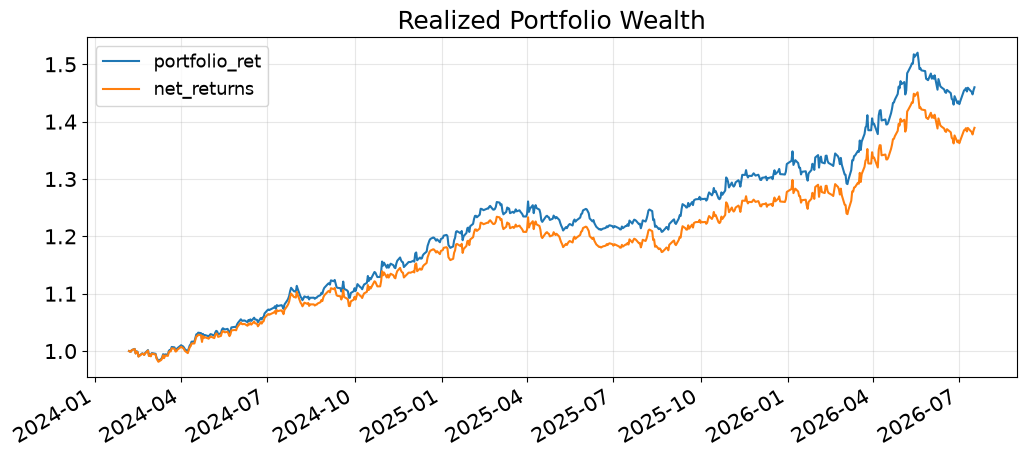

Mean Turnover: 0.16691339687605908
Gross Weight: 3.0
Net Weight: -8.231871320177707e-17
Average Max Weight: 0.04965316939582328


,Annualized Return,Annualized Volatility,Annualized Sharpe Ratio,Annualized Sortino Ratio,Skewness,Excess Kurtosis,VaR (0.05),CVaR (0.05),Min,Max,Max Drawdown,Calmar Ratio,Bottom,Peak,Recovery,Duration (days)
portfolio_ret,0.1601,0.0863,1.8549,2.8428,0.0097,1.5078,-0.0082,-0.0119,-0.0185,0.0237,-0.0595,2.6887,2026-06-25,2026-05-18,-,-
net_returns,0.1390,0.0863,1.6110,2.4638,0.0098,1.5104,-0.0082,-0.0120,-0.0186,0.0236,-0.0614,2.2657,2026-06-25,2026-05-18,-,-


Beta: -0.0034264830287777555
Alpha per rebalance: 0.0006376349802606175
Annualized alpha: 0.1606840150256756
R²: 4.2673496959744206e-05
mean_predicted_alpha_exposure 0.007371260705282728


In [9]:
portfolio_analytics(
    result.portfolio_returns,
    result.target_weights,
    result.pretrade_weights,
    pred_series,
    config=cfg,
    market_beta=True,
)

Based on a sample 2.5 year backtest we see strong performance of 1.6 Sharpe with 5 bps of slippage, minimal drawdowns. Extech's whitepapers show further evidence that the strategy is stable over multiple market regeimes inlcuding in 2008 and 2020, though larger scale testing of this particular strategy would be beneficial. 